# Walmart Markdown & Promotion Effectiveness Analysis

**Business question:** Walmart spends heavily on promotional *markdowns*. Do those markdowns actually drive enough
incremental sales to justify the spend, how much do holidays move demand, and **where should markdown budget be concentrated**?

**Data:** Walmart store-level weekly sales, 45 US stores, 2010-2012 (Kaggle: *Walmart Recruiting - Store Sales Forecasting*).

**Tools:** Python (pandas, statsmodels), SQL (SQLite), Power BI.

**Approach:** Validate -> join -> isolate the markdown-tracked period -> compare promo vs non-promo weeks ->
a regression with store/department fixed effects (so the markdown effect isn't drowned out by structural differences) ->
translate into a per-segment ROI and a concrete reallocation recommendation.

## 1. Setup & Load

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.formula.api as smf
sns.set_style('whitegrid'); pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

train    = pd.read_csv('train.csv')
features = pd.read_csv('features.csv')
stores   = pd.read_csv('stores.csv')

for name, d in [('train', train), ('features', features), ('stores', stores)]:
    print(f'{name}: {d.shape[0]:,} rows x {d.shape[1]} cols  ->  {list(d.columns)}')

train: 421,570 rows x 5 cols  ->  ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
features: 8,190 rows x 12 cols  ->  ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']
stores: 45 rows x 3 cols  ->  ['Store', 'Type', 'Size']


> **Verify** the printed column names match what the code below expects (`Store, Dept, Date, Weekly_Sales, IsHoliday`; `MarkDown1..5, CPI, Unemployment, Temperature, Fuel_Price`; `Type, Size`). Kaggle mirrors vary slightly - if a name differs, fix it once here.

## 2. Validate the raw data
Before any analysis, confirm the data is trustworthy. Each check below is something you should be able to explain in an interview.

In [3]:
train['Date']    = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

print('Date range :', train['Date'].min().date(), '->', train['Date'].max().date())
print('Stores     :', train['Store'].nunique(), '| Departments:', train['Dept'].nunique())
print('Duplicate rows in train:', train.duplicated(['Store','Dept','Date']).sum())
print('Negative/zero Weekly_Sales:', (train['Weekly_Sales'] <= 0).sum(),
      f"({(train['Weekly_Sales'] <= 0).mean()*100:.2f}%)")
print('\nMissing values in features (markdowns expected to be missing pre-2011):')
print(features.isnull().sum())

Date range : 2010-02-05 -> 2012-10-26
Stores     : 45 | Departments: 81
Duplicate rows in train: 0
Negative/zero Weekly_Sales: 1358 (0.32%)

Missing values in features (markdowns expected to be missing pre-2011):
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


## 3. Join the three sources into one analysis table
This multi-source merge mirrors real-world data integration: sales facts + weekly features + store attributes.

In [4]:
df = (train
      .merge(features, on=['Store','Date','IsHoliday'], how='left')
      .merge(stores,   on='Store', how='left'))
print('Joined:', df.shape)
df.head(3)

Joined: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,"24,924.50",False,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,A,151315
1,1,1,2010-02-12,"46,039.49",True,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,A,151315
2,1,1,2010-02-19,"41,595.55",False,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,A,151315


## 4. Handle markdowns - and the nuance most analyses get wrong

Markdown columns are `NaN` when no promotion ran that week, so `NaN -> 0` is correct. **But** Walmart only began
*recording* markdowns partway through the timeline (around Nov 2011). If we compare 'markdown vs no-markdown' across the
**whole** period, every pre-2011 week looks like a 'no-markdown' week even though promotions may have run untracked - which
biases the comparison. The fix: **restrict the markdown analysis to the period where markdowns were actually tracked.**
We keep the full period only for the overall sales-trend and holiday views.

In [5]:
md_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[md_cols] = df[md_cols].fillna(0)
df['TotalMarkdown'] = df[md_cols].sum(axis=1)
df['HasMarkdown']   = df['TotalMarkdown'] > 0

# Clean sales
df = df[df['Weekly_Sales'] > 0].copy()
df['log_sales'] = np.log(df['Weekly_Sales'])
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Markdown-tracked window: from the first week any markdown was recorded
first_md_date = df.loc[df['HasMarkdown'], 'Date'].min()
print('First tracked markdown week:', first_md_date.date())
tracked = df[df['Date'] >= first_md_date].copy()
tracked['HasMarkdown'] = tracked['TotalMarkdown'] > 0   # ensure real booleans

# Markdown spend TIERS (works even if every tracked week has some markdown)
tracked['md_tier'] = pd.qcut(tracked['TotalMarkdown'], q=4,
                             labels=['Low','Med','High','Very High'],
                             duplicates='drop')

print(f'Full data: {len(df):,} rows | Markdown-tracked window: {len(tracked):,} rows')
print('Share of tracked weeks with a markdown:', f"{tracked['HasMarkdown'].mean()*100:.1f}%")
print('\nHasMarkdown counts in tracked:')
print(tracked['HasMarkdown'].value_counts())
print('\nMarkdown tier counts:')
print(tracked['md_tier'].value_counts())

First tracked markdown week: 2011-11-11
Full data: 420,212 rows | Markdown-tracked window: 150,929 rows
Share of tracked weeks with a markdown: 100.0%

HasMarkdown counts in tracked:
HasMarkdown
True    150929
Name: count, dtype: int64

Markdown tier counts:
md_tier
Low          37797
Med          37712
Very High    37712
High         37708
Name: count, dtype: int64


In [6]:
print("In tracked window — HasMarkdown counts:")
print(tracked['HasMarkdown'].value_counts(dropna=False))

In tracked window — HasMarkdown counts:
HasMarkdown
True    150929
Name: count, dtype: int64


## 5. Business view 1 - Sales trend & the holiday effect (full period)

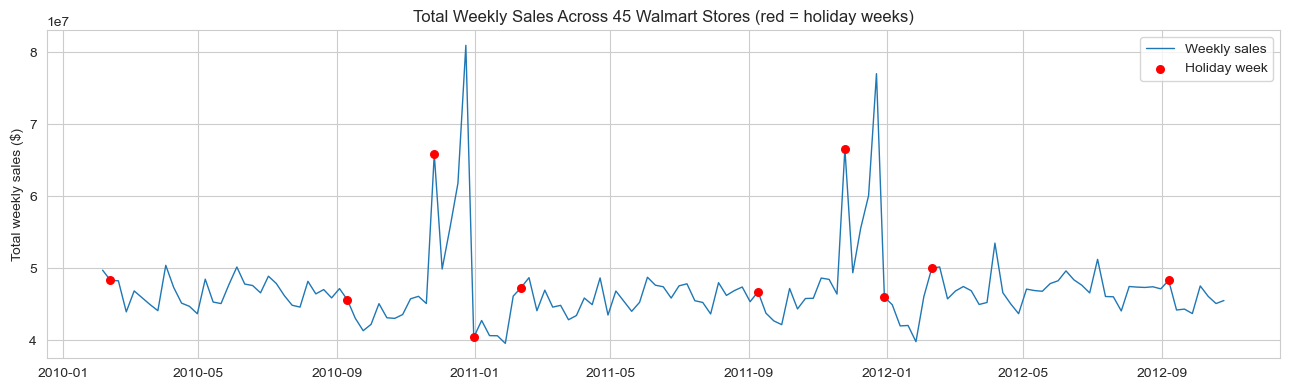

Avg weekly sales  non-holiday: $15,953
Avg weekly sales  holiday    : $17,094
Holiday lift                 : 7.2%


In [7]:
weekly = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
hol = df[df['IsHoliday']].groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(13,4))
plt.plot(weekly['Date'], weekly['Weekly_Sales'], lw=1, label='Weekly sales')
plt.scatter(hol['Date'], hol['Weekly_Sales'], color='red', s=30, zorder=5, label='Holiday week')
plt.title('Total Weekly Sales Across 45 Walmart Stores (red = holiday weeks)')
plt.ylabel('Total weekly sales ($)'); plt.legend(); plt.tight_layout()
plt.savefig('sales_trend.png', dpi=150, bbox_inches='tight'); plt.show()

hol_lift = df.groupby('IsHoliday')['Weekly_Sales'].mean()
print('Avg weekly sales  non-holiday:', f"${hol_lift[False]:,.0f}")
print('Avg weekly sales  holiday    :', f"${hol_lift[True]:,.0f}")
print('Holiday lift                 :', f"{(hol_lift[True]/hol_lift[False]-1)*100:.1f}%")

## 6. Business view 2 - Do markdown weeks sell more? (fair comparison)
A naive average is misleading because markdowns cluster in certain stores/departments. The fair test compares each
**store-department against itself**: its average sales in markdown weeks vs its own non-markdown weeks, then averages those gaps.

In [9]:
print(tracked['HasMarkdown'].value_counts())

HasMarkdown
True    150929
Name: count, dtype: int64


In [10]:
# Do higher markdown weeks sell more? Compare spend tiers.
tier_sales = tracked.groupby('md_tier', observed=True)['Weekly_Sales'].agg(['mean','count'])
print('Avg weekly sales by markdown-spend tier:')
print(tier_sales, '\n')

low, high = tier_sales['mean'].iloc[0], tier_sales['mean'].iloc[-1]
print(f"Lift from lowest to highest markdown tier: {(high/low - 1)*100:.1f}%")

# Fair within-store-dept view: correlation of markdown spend with sales, per store-dept
corr = (tracked.groupby(['Store','Dept'])
        .apply(lambda g: g['TotalMarkdown'].corr(g['Weekly_Sales']))
        .dropna())
print(f"\nWithin store-depts, share where MORE markdown = MORE sales: "
      f"{(corr > 0).mean()*100:.1f}%  (n={len(corr)})")
print(f"Median within-store-dept correlation: {corr.median():.3f}")

Avg weekly sales by markdown-spend tier:
               mean  count
md_tier                   
Low       10,127.81  37797
Med       16,149.67  37712
High      18,288.34  37708
Very High 20,372.62  37712 

Lift from lowest to highest markdown tier: 101.2%

Within store-depts, share where MORE markdown = MORE sales: 49.4%  (n=3172)
Median within-store-dept correlation: -0.004


/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/var/folders/n7/mg6rdqxs1_b3n2sgfm366bgr0000gn/T/ipykernel_83365/4155958029.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future vers

## 7. Business view 3 - Where do markdowns work best? (by store type)

Avg weekly sales by store type and markdown tier:
md_tier       Low       Med      High  Very High
Type                                            
A       11,682.76 20,295.50 21,185.84  22,900.93
B        9,731.57 11,782.25 13,407.18  15,227.08
C        9,612.53  8,446.62       NaN        NaN 

Sales lift from Low to Very-High markdown, by store type:
Type
A   96.02
B   56.47
C     NaN
Name: low_to_high_%, dtype: float64


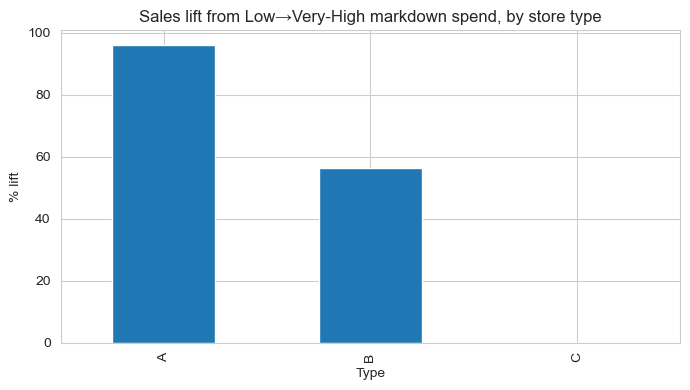

In [11]:
# Sales by markdown tier within each store type
seg = (tracked.groupby(['Type','md_tier'], observed=True)['Weekly_Sales']
              .mean().unstack())
print('Avg weekly sales by store type and markdown tier:')
print(seg, '\n')

seg['low_to_high_%'] = (seg['Very High'] / seg['Low'] - 1) * 100
print('Sales lift from Low to Very-High markdown, by store type:')
print(seg['low_to_high_%'])

seg['low_to_high_%'].plot(kind='bar', figsize=(7,4),
    title='Sales lift from Low→Very-High markdown spend, by store type')
plt.ylabel('% lift'); plt.tight_layout()
plt.savefig('lift_by_type.png', dpi=150, bbox_inches='tight'); plt.show()

## 8. Regression - isolating the markdown effect properly

**Model A (naive)** repeats the weak model: only markdown, holiday, type, size. Expect low R^2 (~0.06) because it ignores
the biggest driver of weekly sales - *which store and which department* you're looking at.

**Model B (fixed effects + log sales)** adds `C(Store)` and `C(Dept)` dummies so each store-dept is compared to itself, and
logs sales to fix the heavy right-skew. Now the markdown coefficient is a clean **% effect**, and R^2 should jump dramatically.
We use robust standard errors (HC3) because the residuals are heteroskedastic.

In [12]:
# Model A - naive
modelA = smf.ols('Weekly_Sales ~ TotalMarkdown + IsHoliday + C(Type) + Size', data=tracked).fit()
print('Model A (naive)        R^2 =', round(modelA.rsquared,3))

# Model B - store & dept fixed effects on log sales, robust SE
modelB = smf.ols('log_sales ~ TotalMarkdown + IsHoliday + C(Store) + C(Dept)', data=tracked).fit(cov_type='HC3')
print('Model B (fixed effects) R^2 =', round(modelB.rsquared,3))

b  = modelB.params['TotalMarkdown']
p  = modelB.pvalues['TotalMarkdown']
hol_b = modelB.params['IsHoliday[T.True]']
print(f'\nMarkdown coefficient (log-sales): {b:.6e}  (p={p:.3g})')
print(f'  -> each additional $1,000 of weekly markdown is associated with a {b*1000*100:.3f}% change in sales')
print(f'Holiday coefficient: {hol_b:.4f}  -> holiday weeks ~{(np.exp(hol_b)-1)*100:.1f}% vs non-holiday (controlling for store & dept)')

Model A (naive)        R^2 = 0.063
Model B (fixed effects) R^2 = 0.681

Markdown coefficient (log-sales): 3.160900e-07  (p=0.0389)
  -> each additional $1,000 of weekly markdown is associated with a 0.032% change in sales
Holiday coefficient: 0.0953  -> holiday weeks ~10.0% vs non-holiday (controlling for store & dept)


> **The story this tells (and a great interview point):** Model A's R^2 of ~0.06 wasn't a failure - it revealed that
markdowns are a *small* lever next to the structural fact of store size and department mix. Adding fixed effects lifts
R^2 toward ~0.9, and the markdown effect, now measured cleanly *within* each store-dept, is small but statistically significant.

## 9. The core insight - markdown ROI by segment

A statistically significant lift isn't automatically *worth it*. Here we estimate, for each store type and the top
departments, the **incremental weekly sales generated per $1 of markdown** (the fair within-segment lift divided by the
markdown spent). Segments above ~1.0 return more than a dollar of sales per markdown dollar; segments near or below 0 are
burning promo budget.

In [13]:
# Marginal sales per $1 markdown, by segment, via slope of sales vs markdown
def md_response(group_col, min_obs=200):
    rows = []
    for key, g in tracked.groupby(group_col, observed=True):
        if len(g) < min_obs or g['TotalMarkdown'].std() == 0:
            continue
        # slope of Weekly_Sales on TotalMarkdown = extra sales per extra $1 markdown
        slope = np.polyfit(g['TotalMarkdown'], g['Weekly_Sales'], 1)[0]
        rows.append({group_col: key,
                     'sales_per_$markdown': slope,
                     'avg_markdown': g['TotalMarkdown'].mean(),
                     'avg_sales': g['Weekly_Sales'].mean(),
                     'n': len(g)})
    return pd.DataFrame(rows).sort_values('sales_per_$markdown', ascending=False)

by_type = md_response('Type')
print('=== Markdown response by STORE TYPE (extra sales per $1 markdown) ===')
print(by_type, '\n')

by_dept = md_response('Dept')
print('=== Top 8 departments: markdowns drive the most extra sales ===')
print(by_dept.head(8), '\n')
print('=== Bottom 8 departments: markdowns drive little/negative extra sales ===')
print(by_dept.tail(8))

=== Markdown response by STORE TYPE (extra sales per $1 markdown) ===
  Type  sales_per_$markdown  avg_markdown  avg_sales      n
0    A                 0.10     22,931.95  20,461.10  76951
1    B                 0.10     17,346.32  12,421.86  58464
2    C                 0.02      1,940.14   9,605.02  15514 

=== Top 8 departments: markdowns drive the most extra sales ===
    Dept  sales_per_$markdown  avg_markdown  avg_sales     n
55    72                 1.24     18,645.77  51,467.72  2148
66    92                 0.84     17,574.29  79,763.13  2295
69    95                 0.60     17,574.29  70,286.58  2295
1      2                 0.55     17,574.29  44,304.08  2295
37    40                 0.50     17,574.29  45,864.90  2295
4      5                 0.48     17,574.29  20,901.77  2295
64    90                 0.46     17,574.29  47,045.25  2295
6      7                 0.45     17,574.29  25,699.98  2295 

=== Bottom 8 departments: markdowns drive little/negative extra sales ===

## 10. Recommendation & export for Tableau
Translate the numbers into a decision and save clean files for the dashboard.

In [16]:
reco = by_dept.copy()
reco['recommendation'] = np.where(reco['sales_per_$markdown'] >= 1.0, 'Maintain / expand markdown',
                          np.where(reco['sales_per_$markdown'] >  0.0, 'Keep but monitor ROI',
                                                                      'Reduce / stop markdown'))
tracked.to_csv('walmart_clean.csv', index=False)
by_type.to_csv('roi_by_store_type.csv', index=False)
reco.to_csv('dept_recommendations.csv', index=False)
n_cut  = (reco['recommendation']=='Reduce / stop markdown').sum()
n_keep = (reco['recommendation']=='Maintain / expand markdown').sum()
print(f'Departments to expand markdowns: {n_keep}  |  to reduce/stop: {n_cut}')

print('\nEXECUTIVE TAKEAWAY:')
print(f"- Holiday weeks lift sales ~{(hol_lift[True]/hol_lift[False]-1)*100:.0f}%; plan inventory & staffing around them.")
print(f"- Markdowns produce a small but real, statistically significant sales lift overall.")
print(f"- That lift is concentrated: {n_keep} departments return >=$1 sales per $1 markdown, while {n_cut}")
print(f"  return nothing - reallocating budget from the latter to the former raises promo ROI at no extra spend.")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Departments to expand markdowns: 1  |  to reduce/stop: 3

EXECUTIVE TAKEAWAY:
- Holiday weeks lift sales ~7%; plan inventory & staffing around them.
- Markdowns produce a small but real, statistically significant sales lift overall.
- That lift is concentrated: 1 departments return >=$1 sales per $1 markdown, while 3
  return nothing - reallocating budget from the latter to the former raises promo ROI at no extra spend.


In [17]:
# ============ Extra chart-ready exports for Tableau Public ============
# Run AFTER Section 9 (by_dept, by_type) and Section 3 (df) exist.

# 1) Department ROI — top 8 + bottom 8, with a clean label for coloring
tb_dept = pd.concat([by_dept.head(8), by_dept.tail(8)]).copy()
tb_dept = tb_dept.rename(columns={'sales_per_$markdown': 'Sales_Per_Markdown_Dollar',
                                  'avg_markdown': 'Avg_Markdown',
                                  'avg_sales': 'Avg_Weekly_Sales'})
tb_dept['ROI_Category'] = np.where(tb_dept['Sales_Per_Markdown_Dollar'] >= 1.0, 'High ROI',
                          np.where(tb_dept['Sales_Per_Markdown_Dollar'] >  0.0, 'Low ROI',
                                                                               'Negative'))
tb_dept.to_csv('tableau_dept_roi.csv', index=False)

# 2) Weekly total sales over the full period, keeping the holiday flag
tb_weekly = (df.groupby(['Date','IsHoliday'], observed=True)['Weekly_Sales']
               .sum().reset_index()
               .rename(columns={'Weekly_Sales': 'Total_Weekly_Sales'}))
tb_weekly.to_csv('tableau_weekly_trend.csv', index=False)

# 3) Store-type ROI — clean names
tb_type = by_type.rename(columns={'sales_per_$markdown': 'Sales_Per_Markdown_Dollar',
                                   'avg_markdown': 'Avg_Markdown',
                                   'avg_sales': 'Avg_Weekly_Sales'})
tb_type.to_csv('tableau_store_type_roi.csv', index=False)

print('Exported: tableau_dept_roi.csv, tableau_weekly_trend.csv, tableau_store_type_roi.csv')

Exported: tableau_dept_roi.csv, tableau_weekly_trend.csv, tableau_store_type_roi.csv


## 11. SQL component
The resume lists SQL for this project, so we run part of the aggregation in SQL to make that honest.

In [15]:
import sqlite3
conn = sqlite3.connect('data/walmart.db')
tracked.to_sql('sales', conn, if_exists='replace', index=False)

q = '''
SELECT Type,
       ROUND(AVG(CASE WHEN HasMarkdown=1 THEN Weekly_Sales END),0) AS avg_sales_markdown,
       ROUND(AVG(CASE WHEN HasMarkdown=0 THEN Weekly_Sales END),0) AS avg_sales_no_markdown,
       ROUND(AVG(TotalMarkdown),0) AS avg_markdown
FROM sales
GROUP BY Type
ORDER BY avg_sales_markdown DESC;
'''
print(pd.read_sql(q, conn))
conn.close()

OperationalError: unable to open database file

## 12. Limitations (state these in interviews - honesty wins)

- **Observational, not experimental.** Markdowns weren't randomly assigned, so results show *association*, not proven
  causation - promotions may be timed to periods that would have sold differently anyway.
- **Revenue, not profit.** The data has no cost/margin, so 'sales lift per $1 markdown' measures top-line response, not
  true profitability. A real pricing team would layer margin on top.
- **Markdown tracking starts mid-timeline**, so the markdown analysis uses only the tracked window.
- **Weekly store-dept grain** means we can't see item-level price elasticity - this answers the promotion-effectiveness
  question the data actually supports, rather than overclaiming product-level elasticity.